# temporal predictions 

Minimal notebook setup for exploring predictive coding with NumPy, PyTorch, and torchvision.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
import math
import os as os

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")

Using device: cpu
PyTorch: 2.13.0
NumPy: 2.5.2


dataset/input variables

In [31]:
if not os.path.exists("./data/MovingMNIST/mnist_test_seq.npy"):
    datasets.MovingMNIST._URL = "https://huggingface.co/datasets/goodgoodideas/STDN/resolve/main/mnist_test_seq.npy"
input_data = datasets.MovingMNIST(root="./data", split=None, download=True)

In [32]:
def make_variables(image, initial_r_size=64, num_channels=16, num_layers=2, kernel_size=4, padding=1, stride=2):
    I = image
    r = []
    deconvs = []
    previous_num_channels = I.shape[0] if I.ndim == 3 else 1
    out_channels = num_channels * 2
    for i in range(num_layers):
        r_size = initial_r_size // (2 ** (i + 1))
        r.append(torch.randn(1, out_channels, r_size, r_size) * 0.01)
        deconvs.append(nn.ConvTranspose2d(out_channels, previous_num_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False))
        previous_num_channels = out_channels
        out_channels = out_channels * 2
    return I, r, deconvs

temporal nn

In [33]:
class TemporalNN(nn.Module):
    def __init__(self, r, hidden_dim=256):
        super().__init__()
        self.mlps = nn.ModuleList()
        for ri in r:
            in_dim = ri[0].numel()
            mlp = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, in_dim),
            )
            nn.init.zeros_(mlp[-1].weight)
            nn.init.zeros_(mlp[-1].bias)
            self.mlps.append(mlp)

    def forward(self, r_prev):
        r_hat = []
        for mlp, ri in zip(self.mlps, r_prev):
            delta = mlp(ri.reshape(ri.shape[0], -1)).view_as(ri)
            r_hat.append(ri + delta)
        return r_hat

Training Loop

In [34]:


def train_loop(I_curr, r_prev, r_curr, alpha, lambda_u, lr_r, lr_u,sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, temporal_nn):
    I_curr = I_curr.float()
    if I_curr.ndim == 3:
        I_curr = I_curr.unsqueeze(0)
    e_spatial = [None] * num_layers
    e_temporal = [None] * num_layers
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    if r_prev is None:
        r_prev = [torch.zeros_like(ri) for ri in r_curr]
    else:
        r_prev = [ri.detach() for ri in r_prev]

    
    for out_epoch in range(num_epochs_outer):
        r_prev = [ri.detach() for ri in r_prev]
        r_pred = temporal_nn(r_prev)
        for in_epoch in range(num_epochs_inner):
            e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))

            for i in range(1, num_layers):
                e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))
            
            for i in range(num_layers):
                cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                dr = (1.0 / sigma_2) * bottom_up - cauchy_prior - (1.0 / sigma_2) * (r_curr[i] - r_pred[i])
                if i < num_layers - 1:
                    dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                r_curr[i] = (r_curr[i] + lr_r * dr).detach()
                r_curr[i].requires_grad = True

        e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
        r_pred = temporal_nn(r_prev)
        total_loss = 0

        for j in range(num_layers):
            if j > 0:
                e_spatial[j] = r_curr[j - 1] - f(deconvs[j](r_curr[j]))
            e_temporal[j] = r_curr[j] - r_pred[j]

            total_loss += (1.0 / (2 * sigma_2)) * (torch.sum(e_spatial[j]**2) + torch.sum(e_temporal[j]**2))

            deconvs[j].zero_grad()
        temporal_nn.zero_grad()
        
        total_loss.backward()
        
        
        
    
        with torch.no_grad():
            for j in range(num_layers):
                if deconvs[j].weight.grad is not None:
                    deconvs[j].weight -= lr_u * (deconvs[j].weight.grad + lambda_u * deconvs[j].weight)
                    deconvs[j].weight /= (torch.linalg.vector_norm(deconvs[j].weight, ord=2, dim=(1, 2, 3), keepdim=True) + 1e-8)
                    deconvs[j].weight.grad = None
            for param in temporal_nn.parameters():
                if param.grad is not None:
                    param -= lr_u * (param.grad + lambda_u * param)
                    param /= (torch.linalg.vector_norm(param, ord=2) + 1e-8)
                    param.grad = None

    return r_curr


validation


In [35]:
def validate_heirarchical(I, r_curr, r_prev, num_layers, deconvs, temporal_nn):
    I = I.float()
    if I.ndim == 3:
        I = I.unsqueeze(0)

    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    if r_prev is None:
        r_prev = [torch.zeros_like(ri) for ri in r_curr]
        
    r_prev = [ri.detach() for ri in r_prev]

    with torch.no_grad():
        r_pred = temporal_nn(r_prev)
        
        I_hat_L0 = deconvs[0](r_pred[0])
        
        h = r_pred[num_layers - 1]
        for i in range(num_layers - 1, -1, -1):
            h = f(deconvs[i](h))
        I_hat_top_down = h
        
        mse_L0 = torch.mean((I - I_hat_L0) ** 2)
        mse_top_down = torch.mean((I - I_hat_top_down) ** 2)
    
    return mse_L0, mse_top_down, I_hat_L0, I_hat_top_down


test it

In [36]:
def test(I, r_curr, r_prev, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn):
    I_curr = I.float()
    if I_curr.ndim == 3:
        I_curr = I_curr.unsqueeze(0)
    e_spatial = [None] * num_layers

    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    
    if r_prev is None:
        r_prev = [torch.zeros_like(ri) for ri in r_curr]

    r_prev = [ri.detach() for ri in r_prev]

    
    with torch.no_grad():
        r_pred = temporal_nn(r_prev)
        for in_epoch in range(num_epochs_inner):
            e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))

            for i in range(1, num_layers):
                    e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))
                
            for i in range(num_layers):
                cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                dr = (1.0 / sigma_2) * bottom_up - cauchy_prior - (1.0 / sigma_2) * (r_curr[i] - r_pred[i])
                if i < num_layers - 1:
                    dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                r_curr[i] = (r_curr[i] + lr_r * dr).detach()
                r_curr[i].requires_grad = True
    return r_curr


Starting Training: 20 Epochs | 20 Sequences | 2 Layers
Hyperparameters: lr_r=0.005, lr_U=0.002, alpha=0.001, lambda_u=0.001
[Epoch 000/020]  Layer 0 MSE: 0.004950 (|r0|: 0.0094)  |  Layer 1 MSE: 0.034378 (|r1|: 0.0109)


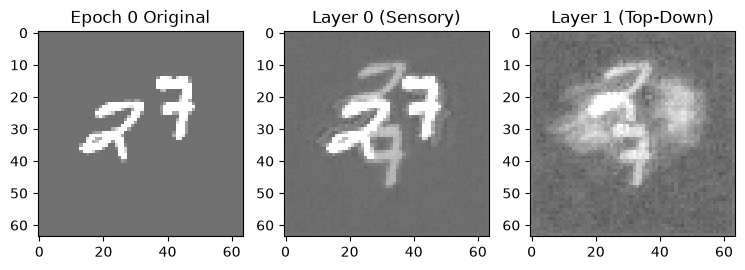

[Epoch 005/020]  Layer 0 MSE: 0.001077 (|r0|: 0.0076)  |  Layer 1 MSE: 0.021652 (|r1|: 0.0076)


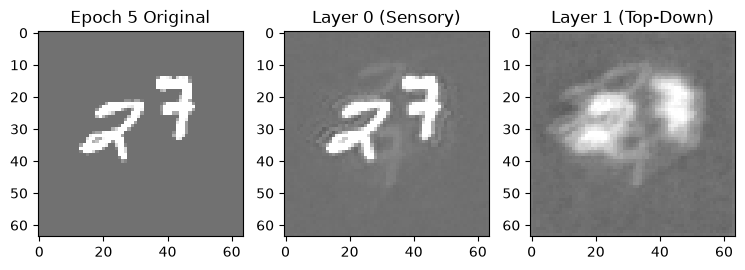

[Epoch 010/020]  Layer 0 MSE: 0.000902 (|r0|: 0.0072)  |  Layer 1 MSE: 0.018285 (|r1|: 0.0071)


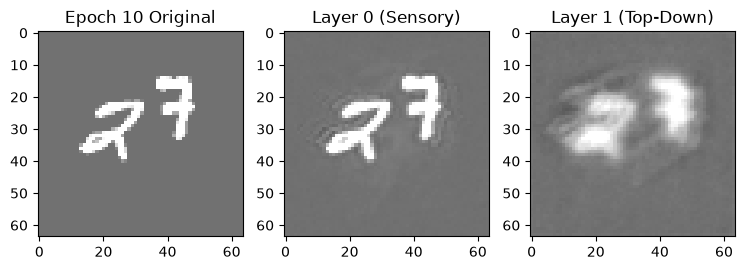

[Epoch 015/020]  Layer 0 MSE: 0.000908 (|r0|: 0.0071)  |  Layer 1 MSE: 0.016409 (|r1|: 0.0071)


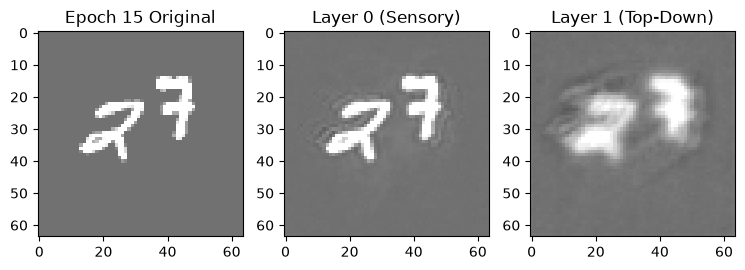

[Epoch 019/020]  Layer 0 MSE: 0.000920 (|r0|: 0.0071)  |  Layer 1 MSE: 0.015230 (|r1|: 0.0071)


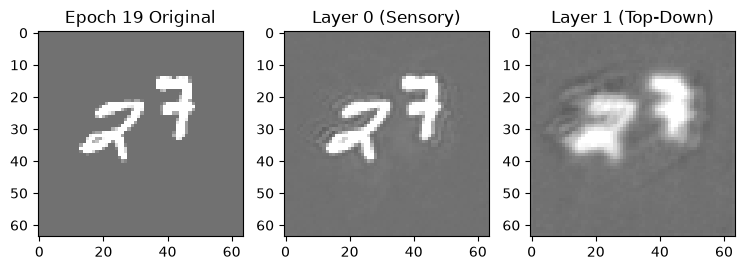

TypeError: test() missing 2 required positional arguments: 'deconvs' and 'temporal_nn'

In [41]:
def main():
    num_data = 20
    T_use = 10
    sequences = [input_data[i].float() / 255.0 for i in range(num_data)]
    num_train_epochs = 20
    alpha = 0.001
    lambda_u = 0.001
    lr_r = 0.005
    lr_U = 0.002
    sigma_2 = 1.0
    num_layers = 2

    num_epochs_inner = 50
    num_epochs_outer = 1
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    print("=" * 60)
    print(f"Starting Training: {num_train_epochs} Epochs | {num_data} Sequences | {num_layers} Layers")
    print(f"Hyperparameters: lr_r={lr_r}, lr_U={lr_U}, alpha={alpha}, lambda_u={lambda_u}")
    print("=" * 60)

    _, r_init, deconvs = make_variables(sequences[0][0], num_layers=num_layers)
    temporal_nn = TemporalNN(r_init)

    for epoch in range(num_train_epochs):
        for seq in sequences:
            r_prev = [ri.clone() for ri in r_init]
            r_curr = [ri.clone() for ri in r_init]
            for t in range(1, T_use):
                I = seq[t] - seq[t].mean()
                r_curr = train_loop(I, r_prev, r_curr, alpha, lambda_u, lr_r, lr_U, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, temporal_nn)
                r_prev = [ri.detach().clone() for ri in r_curr]

        if epoch % 5 == 0 or epoch == num_train_epochs - 1:
            seq = sequences[0]
            r_prev = [ri.clone() for ri in r_init]
            r_curr = [ri.clone() for ri in r_init]
            for t in range(1, T_use - 1):
                I = seq[t] - seq[t].mean()
                r_curr = test(I, r_curr, r_prev, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn)
                r_prev = [ri.detach().clone() for ri in r_curr]

            I_curr = seq[T_use - 2] - seq[T_use - 2].mean()
            I_next = seq[T_use - 1] - seq[T_use - 1].mean()
            r_curr = test(I_curr, r_curr, r_prev, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn)

            with torch.no_grad():
                r_pred_next = temporal_nn([ri.detach() for ri in r_curr])
                I_next_hat = f(deconvs[0](r_pred_next[0]))
                mse_next = torch.mean((I_next - I_next_hat) ** 2).item()

            r_next = [ri.clone() for ri in r_init]
            r_next = test(I_next, r_next, r_curr, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn)
            with torch.no_grad():
                mse_temporal = 0.0
                for j in range(num_layers):
                    mse_temporal += torch.mean((r_next[j] - r_pred_next[j]) ** 2).item()

            print(f"[Epoch {epoch:03d}/{num_train_epochs:03d}]  Next-frame MSE: {mse_next:.6f}  |  TemporalNN MSE: {mse_temporal:.6f}")

            fig, axes = plt.subplots(1, 3, figsize=(9, 3))
            axes[0].imshow(I_curr.reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
            axes[0].set_title(f"Epoch {epoch} Frame t")
            axes[1].imshow(I_next.reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
            axes[1].set_title("True t+1")
            axes[2].imshow(I_next_hat.reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
            axes[2].set_title("Predicted t+1")
            plt.show()

    val_seq = input_data[num_data].float() / 255.0
    r_prev = [ri.clone() for ri in r_init]
    r_curr = [ri.clone() for ri in r_init]
    for t in range(1, T_use - 1):
        I = val_seq[t] - val_seq[t].mean()
        r_curr = test(I, r_curr, r_prev, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn)
        r_prev = [ri.detach().clone() for ri in r_curr]

    I_curr = val_seq[T_use - 2] - val_seq[T_use - 2].mean()
    I_next = val_seq[T_use - 1] - val_seq[T_use - 1].mean()
    r_curr = test(I_curr, r_curr, r_prev, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn)

    with torch.no_grad():
        r_pred_next = temporal_nn([ri.detach() for ri in r_curr])
        I_next_hat = f(deconvs[0](r_pred_next[0]))
        mse_next = torch.mean((I_next - I_next_hat) ** 2).item()

    r_next = [ri.clone() for ri in r_init]
    r_next = test(I_next, r_next, r_curr, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn)
    with torch.no_grad():
        mse_temporal = 0.0
        for j in range(num_layers):
            mse_temporal += torch.mean((r_next[j] - r_pred_next[j]) ** 2).item()

    print(f"Validation  ->  Next-frame MSE: {mse_next:.6f}  |  TemporalNN MSE: {mse_temporal:.6f}")

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(I_curr.reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
    axes[0].set_title("Validation Frame t")
    axes[1].imshow(I_next.reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
    axes[1].set_title("True t+1")
    axes[2].imshow(I_next_hat.reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
    axes[2].set_title("Predicted t+1")
    plt.show()

if __name__ == "__main__":
    main()
